In [2]:
# # Após instalar as dependências, você deve reiniciar o ambiente de inicialização.
# # Rode esta célula sozinha no início da execução que o notebook vai reiniciar automaticamente.
# !pip install ucimlrepo
# !pip install pmdarima
# !pip install prophet
# !pip install numpy==1.26.4 # <-- incluir versão do NumPy
# exit() # para reniciar o notebook depois de instalado

In [1]:
# !pip install ucimlrepo
# exit()

# Importando a biblioteca

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt

from datetime import datetime
from pmdarima.arima import auto_arima
from prophet import Prophet
from prophet.plot import plot_plotly, plot_components_plotly
from statsmodels.tsa.seasonal import seasonal_decompose
from ucimlrepo import fetch_ucirepo

Prever a qualidade do ar em um determinado horário

# Séries temporais

## Base de dados qualidade do ar

### Download e preparação dos dados

Neste exercício, você vai utilizar uma base de dados que contém medições relacionadas a qualidade do ar.

Documentação do dataset: https://archive.ics.uci.edu/dataset/360/air+quality


> O conjunto de dados contém 9358 instâncias de respostas médias horárias de uma matriz de 5 sensores químicos de óxidos metálicos embutidos em um Dispositivo Multissensor de Qualidade do Ar. O dispositivo foi localizado em uma área significativamente poluída, ao nível da estrada, em uma cidade italiana. Os dados foram registrados de março de 2004 a fevereiro de 2005 (um ano), representando as gravações mais longas disponíveis gratuitamente das respostas de dispositivos de sensores químicos de qualidade do ar implantados no campo.
>
> Características do Conjunto de Dados:
> * Número de Instâncias: 9358
> * Número de Recursos: 15

https://github.com/uci-ml-repo/ucimlrepo

In [13]:
air_quality = fetch_ucirepo(id=360)
base = air_quality.data.features # direto do repositório UCI
base

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,3/10/2004,18:00:00,2.6,1360,150,11.9,1046,166,1056,113,1692,1268,13.6,48.9,0.7578
1,3/10/2004,19:00:00,2.0,1292,112,9.4,955,103,1174,92,1559,972,13.3,47.7,0.7255
2,3/10/2004,20:00:00,2.2,1402,88,9.0,939,131,1140,114,1555,1074,11.9,54.0,0.7502
3,3/10/2004,21:00:00,2.2,1376,80,9.2,948,172,1092,122,1584,1203,11.0,60.0,0.7867
4,3/10/2004,22:00:00,1.6,1272,51,6.5,836,131,1205,116,1490,1110,11.2,59.6,0.7888
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9352,4/4/2005,10:00:00,3.1,1314,-200,13.5,1101,472,539,190,1374,1729,21.9,29.3,0.7568
9353,4/4/2005,11:00:00,2.4,1163,-200,11.4,1027,353,604,179,1264,1269,24.3,23.7,0.7119
9354,4/4/2005,12:00:00,2.4,1142,-200,12.4,1063,293,603,175,1241,1092,26.9,18.3,0.6406
9355,4/4/2005,13:00:00,2.1,1003,-200,9.5,961,235,702,156,1041,770,28.3,13.5,0.5139


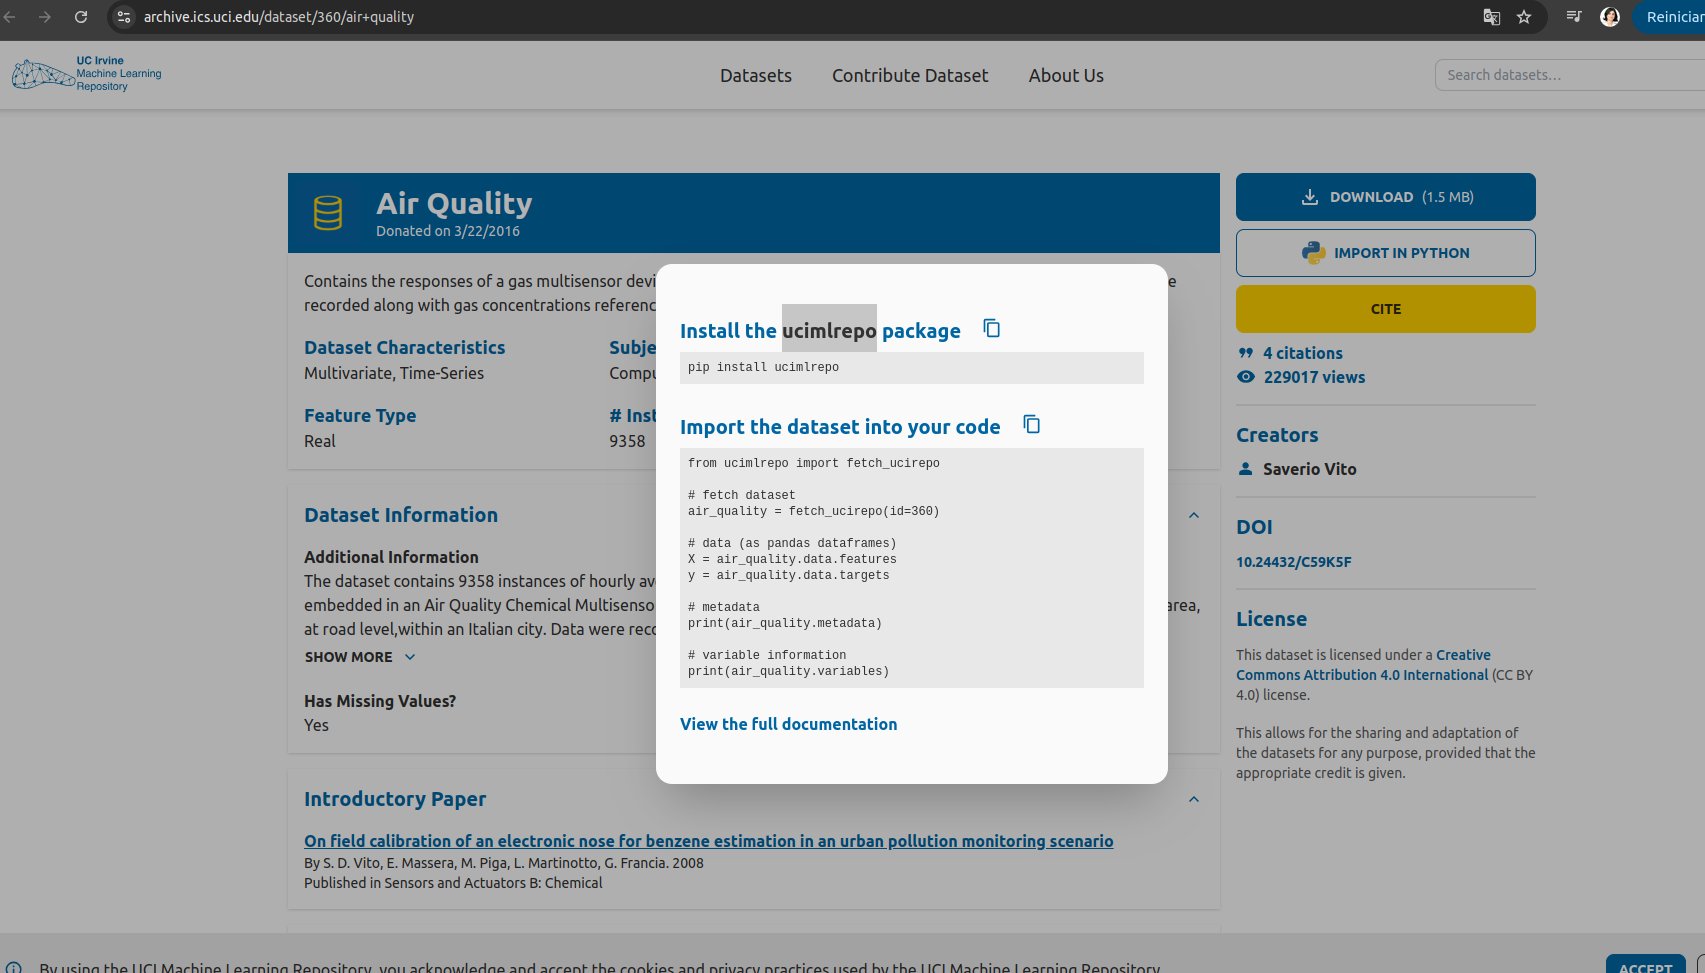

In [5]:
# data (as pandas dataframes) 
X = air_quality.data.features 
y = air_quality.data.targets 
  

In [6]:
X.tail()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
9352,4/4/2005,10:00:00,3.1,1314,-200,13.5,1101,472,539,190,1374,1729,21.9,29.3,0.7568
9353,4/4/2005,11:00:00,2.4,1163,-200,11.4,1027,353,604,179,1264,1269,24.3,23.7,0.7119
9354,4/4/2005,12:00:00,2.4,1142,-200,12.4,1063,293,603,175,1241,1092,26.9,18.3,0.6406
9355,4/4/2005,13:00:00,2.1,1003,-200,9.5,961,235,702,156,1041,770,28.3,13.5,0.5139
9356,4/4/2005,14:00:00,2.2,1071,-200,11.9,1047,265,654,168,1129,816,28.5,13.1,0.5028


In [9]:
print(y)

None


In [11]:

# metadata 
print(air_quality.metadata) 


{'uci_id': 360, 'name': 'Air Quality', 'repository_url': 'https://archive.ics.uci.edu/dataset/360/air+quality', 'data_url': 'https://archive.ics.uci.edu/static/public/360/data.csv', 'abstract': 'Contains the responses of a gas multisensor device deployed on the field in an Italian city. Hourly responses averages are recorded along with gas concentrations references from a certified analyzer. ', 'area': 'Computer Science', 'tasks': ['Regression'], 'characteristics': ['Multivariate', 'Time-Series'], 'num_instances': 9358, 'num_features': 15, 'feature_types': ['Real'], 'demographics': [], 'target_col': None, 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2008, 'last_updated': 'Sun Mar 10 2024', 'dataset_doi': '10.24432/C59K5F', 'creators': ['Saverio Vito'], 'intro_paper': {'ID': 420, 'type': 'NATIVE', 'title': 'On field calibration of an electronic nose for benzene estimation in an urban pollution monitoring scenario', 'authors': 

In [12]:
  
# variable information 
print(air_quality.variables) 


             name     role         type demographic  \
0            Date  Feature         Date        None   
1            Time  Feature  Categorical        None   
2          CO(GT)  Feature      Integer        None   
3     PT08.S1(CO)  Feature  Categorical        None   
4        NMHC(GT)  Feature      Integer        None   
5        C6H6(GT)  Feature   Continuous        None   
6   PT08.S2(NMHC)  Feature  Categorical        None   
7         NOx(GT)  Feature      Integer        None   
8    PT08.S3(NOx)  Feature  Categorical        None   
9         NO2(GT)  Feature      Integer        None   
10   PT08.S4(NO2)  Feature  Categorical        None   
11    PT08.S5(O3)  Feature  Categorical        None   
12              T  Feature   Continuous        None   
13             RH  Feature   Continuous        None   
14             AH  Feature   Continuous        None   

                                          description       units  \
0                                                N

# dados indisponíveis como -200

Perceba na visualização do DataFrame, na coluna `NMHC(GT)`, que medidas indisponíveis estão registradas como $-200$. Para evitar trabalhar com estes valores, vamos recuperar somente as primeiras 500 entradas do dataset.

In [14]:
base = base[:500]

In [15]:
base.tail()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
495,3/31/2004,9:00:00,2.2,1262,216,8.6,924,181,872,125,1576,1093,10.4,74.4,0.9384
496,3/31/2004,10:00:00,1.7,1197,117,6.5,837,144,957,118,1498,965,11.5,71.0,0.9582
497,3/31/2004,11:00:00,1.9,1277,156,7.7,886,140,902,109,1579,1004,12.2,70.0,0.9924
498,3/31/2004,12:00:00,2.9,1430,332,11.3,1025,204,779,123,1772,1166,12.3,73.3,1.0442
499,3/31/2004,13:00:00,2.2,1242,232,9.1,944,149,846,114,1638,991,11.3,78.1,1.0411


juntar a data com o horário

Agora vamos criar uma coluna `Datetime` que vai juntar os dados das colunas `Date` e `Time`, e converter o resultado no formato `datetime`. Também vamos transformar esta coluna no índice de `base`, e para a construção de `time_series`, vamos recuperar somente a variável `T`, que representa a temperatura em graus Celsius.

data completa + temperatura 

In [16]:
base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           500 non-null    object 
 1   Time           500 non-null    object 
 2   CO(GT)         500 non-null    float64
 3   PT08.S1(CO)    500 non-null    int64  
 4   NMHC(GT)       500 non-null    int64  
 5   C6H6(GT)       500 non-null    float64
 6   PT08.S2(NMHC)  500 non-null    int64  
 7   NOx(GT)        500 non-null    int64  
 8   PT08.S3(NOx)   500 non-null    int64  
 9   NO2(GT)        500 non-null    int64  
 10  PT08.S4(NO2)   500 non-null    int64  
 11  PT08.S5(O3)    500 non-null    int64  
 12  T              500 non-null    float64
 13  RH             500 non-null    float64
 14  AH             500 non-null    float64
dtypes: float64(5), int64(8), object(2)
memory usage: 58.7+ KB


In [17]:
base['Datetime'] = pd.to_datetime(base['Date'] + ' ' + base['Time'])
base.index = base["Datetime"]
base.tail()

/tmp/ipykernel_6187/3490884860.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  base['Datetime'] = pd.to_datetime(base['Date'] + ' ' + base['Time'])


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Datetime
Datetime,,,,,,,,,,,,,,,,
2004-03-31 09:00:00,3/31/2004,9:00:00,2.2,1262,216,8.6,924,181,872,125,1576,1093,10.4,74.4,0.9384,2004-03-31 09:00:00
2004-03-31 10:00:00,3/31/2004,10:00:00,1.7,1197,117,6.5,837,144,957,118,1498,965,11.5,71.0,0.9582,2004-03-31 10:00:00
2004-03-31 11:00:00,3/31/2004,11:00:00,1.9,1277,156,7.7,886,140,902,109,1579,1004,12.2,70.0,0.9924,2004-03-31 11:00:00
2004-03-31 12:00:00,3/31/2004,12:00:00,2.9,1430,332,11.3,1025,204,779,123,1772,1166,12.3,73.3,1.0442,2004-03-31 12:00:00
2004-03-31 13:00:00,3/31/2004,13:00:00,2.2,1242,232,9.1,944,149,846,114,1638,991,11.3,78.1,1.0411,2004-03-31 13:00:00


In [18]:
time_series = base["T"]
time_series

Datetime
2004-03-10 18:00:00    13.6
2004-03-10 19:00:00    13.3
2004-03-10 20:00:00    11.9
2004-03-10 21:00:00    11.0
2004-03-10 22:00:00    11.2
                       ... 
2004-03-31 09:00:00    10.4
2004-03-31 10:00:00    11.5
2004-03-31 11:00:00    12.2
2004-03-31 12:00:00    12.3
2004-03-31 13:00:00    11.3
Name: T, Length: 500, dtype: float64

In [19]:
time_series.info()

<class 'pandas.core.series.Series'>
DatetimeIndex: 500 entries, 2004-03-10 18:00:00 to 2004-03-31 13:00:00
Series name: T
Non-Null Count  Dtype  
--------------  -----  
500 non-null    float64
dtypes: float64(1)
memory usage: 7.8 KB


### Exploração dos dados

Recupere a primeira entrada da série temporal. Na versão mais recente do Pandas, você deve explicitamente utilizar o método `iloc`.

In [20]:
time_series.iloc[0]

np.float64(13.6)

pegar a data 

Recupere as medidas para o dia `2004-03-10`.

In [21]:
time_series["2004-03-10"]

Datetime
2004-03-10 18:00:00    13.6
2004-03-10 19:00:00    13.3
2004-03-10 20:00:00    11.9
2004-03-10 21:00:00    11.0
2004-03-10 22:00:00    11.2
2004-03-10 23:00:00    11.2
Name: T, dtype: float64

Recupere as medidas para o dia `2004-03-12`.

In [27]:
time_series["2004-03-12"]

Datetime
2004-03-12 00:00:00     8.3
2004-03-12 01:00:00     7.7
2004-03-12 02:00:00     7.1
2004-03-12 03:00:00     7.0
2004-03-12 04:00:00     6.1
2004-03-12 05:00:00     6.3
2004-03-12 06:00:00     6.8
2004-03-12 07:00:00     6.4
2004-03-12 08:00:00     7.3
2004-03-12 09:00:00     9.2
2004-03-12 10:00:00    13.2
2004-03-12 11:00:00    14.3
2004-03-12 12:00:00    15.0
2004-03-12 13:00:00    16.1
2004-03-12 14:00:00    16.3
2004-03-12 15:00:00    15.8
2004-03-12 16:00:00    15.9
2004-03-12 17:00:00    16.9
2004-03-12 18:00:00    15.1
2004-03-12 19:00:00    14.4
2004-03-12 20:00:00    12.9
2004-03-12 21:00:00    12.1
2004-03-12 22:00:00    11.0
2004-03-12 23:00:00     9.7
Name: T, dtype: float64

Recupere a medida para a hora `18:00` do dia `2004-03-10`. Você precisa usar um objeto `datetime` para isso.

In [28]:
time_series[datetime(2004, 3, 10, 18, 0)]

np.float64(13.6)

Exiba o timestamp mínimo e máximo das medições.

In [29]:
time_series.index.min(), time_series.index.max()

(Timestamp('2004-03-10 18:00:00'), Timestamp('2004-03-31 13:00:00'))

## Plote a série temporal.

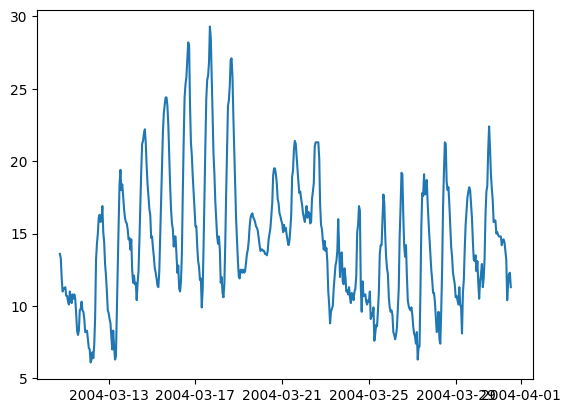

In [30]:
plt.plot(time_series)

Faça uma reamostragem da série temporal por dia (parâmetro `"D"`), agredada pela média (método `mean`). Plote essa reamostragem.

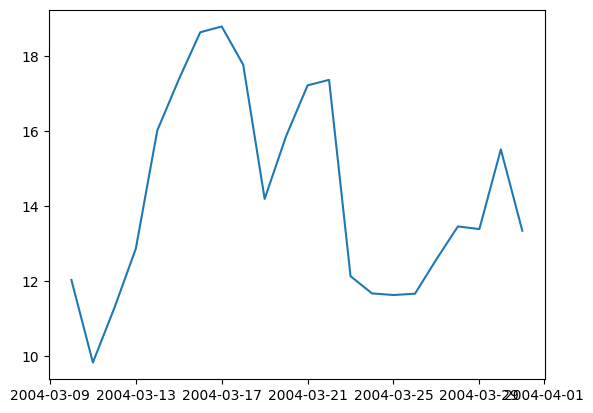

In [34]:
time_series_day = time_series.resample("D").mean() # cálculo da média diária
plt.plot(time_series_day)

Faça uma nova reamostragem média por hora (parâmetro `hour`), mas agora utilizando o método `groupby` da série temporal. Plote o resultado.

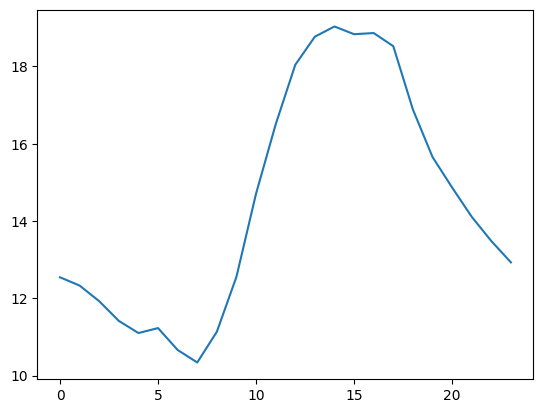

In [33]:
time_series_hour = time_series.groupby([lambda x: x.hour]).mean() # cálculo da média por hora
plt.plot(time_series_hour)

Utilize `season_decompose` para decompor a série temporal, recupere os atributos relacionados à tendência, sazonalidade e resíduos, e na sequência plote esses atributos.

In [35]:
decomposition = seasonal_decompose(time_series)
tendency = decomposition.trend
sazonality = decomposition.seasonal
residual = decomposition.resid

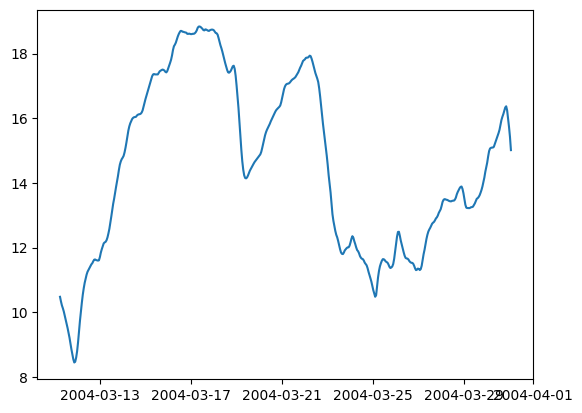

In [36]:
plt.plot(tendency)

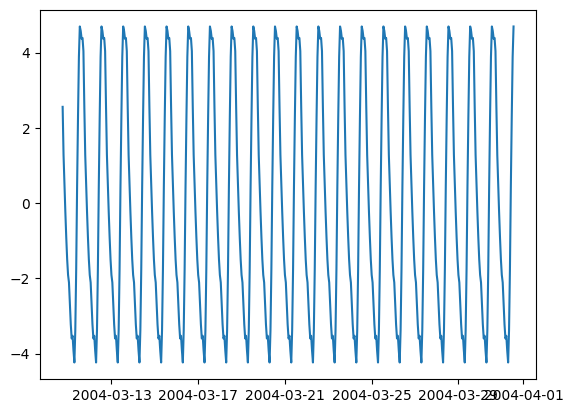

In [37]:
plt.plot(sazonality)


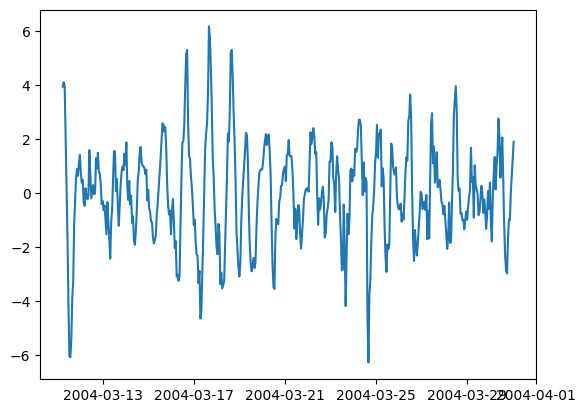

In [38]:
plt.plot(residual)

### Ajuste um modelo do time Arima com os dados da série temporal.

### ARIMA (AutoRegressive Integrated Moving Average)

o modelo ARIMA utiliza dados passados para prever valores futuros, levando em conta a autocorrelação e a diferenciação, permitindo capturar padrões temporais de maneira eficaz. Isso torna o ARIMA uma ferramenta poderosa para análises de séries temporais.


In [39]:
model = auto_arima(time_series)

In [40]:
model.get_params()

{'maxiter': 50,
 'method': 'lbfgs',
 'order': (2, 1, 1),
 'out_of_sample_size': 0,
 'scoring': 'mse',
 'scoring_args': {},
 'seasonal_order': (0, 0, 0, 0),
 'start_params': None,
 'suppress_warnings': True,
 'trend': None,
 'with_intercept': False}

Exiba os valores de ordem no atributo `order`.

In [41]:
model.order

(2, 1, 1)

### Faça predições para 24 períodos.

In [42]:
predictions = model.predict(n_periods=24, suppress_warnings=True)

In [43]:
predictions.tail()

2004-04-01 09:00:00    13.703519
2004-04-01 10:00:00    13.696424
2004-04-01 11:00:00    13.690055
2004-04-01 12:00:00    13.684669
2004-04-01 13:00:00    13.680331
Freq: h, dtype: float64

Exiba as predições.

In [44]:
predictions

2004-03-31 14:00:00    10.918623
2004-03-31 15:00:00    10.934580
2004-03-31 16:00:00    11.182957
2004-03-31 17:00:00    11.546412
2004-03-31 18:00:00    11.945846
2004-03-31 19:00:00    12.331571
2004-03-31 20:00:00    12.675545
2004-03-31 21:00:00    12.964912
2004-03-31 22:00:00    13.196877
2004-03-31 23:00:00    13.374807
2004-04-01 00:00:00    13.505401
2004-04-01 01:00:00    13.596737
2004-04-01 02:00:00    13.656994
2004-04-01 03:00:00    13.693702
2004-04-01 04:00:00    13.713346
2004-04-01 05:00:00    13.721233
2004-04-01 06:00:00    13.721514
2004-04-01 07:00:00    13.717294
2004-04-01 08:00:00    13.710793
2004-04-01 09:00:00    13.703519
2004-04-01 10:00:00    13.696424
2004-04-01 11:00:00    13.690055
2004-04-01 12:00:00    13.684669
2004-04-01 13:00:00    13.680331
Freq: h, dtype: float64

Exiba o tamanho da série temporal.

In [47]:
print(f'Exiba o tamanho da série temporal.: {len(time_series)}.')

Exiba o tamanho da série temporal.: 500.


Separe os primeiros 490 períodos como dados de treino, e os restantes 10 como dados de teste.

In [48]:
train = time_series[:490]
test = time_series[490:]

Retreine o modelo, mas agora utilizando somente os dados de treino.

In [49]:
model = auto_arima(train)

In [50]:
model.get_params()

{'maxiter': 50,
 'method': 'lbfgs',
 'order': (2, 1, 1),
 'out_of_sample_size': 0,
 'scoring': 'mse',
 'scoring_args': {},
 'seasonal_order': (0, 0, 0, 0),
 'start_params': None,
 'suppress_warnings': True,
 'trend': None,
 'with_intercept': False}

## Gere predições para os 10 períodos seguintes.

In [52]:
model.order

(2, 1, 1)

In [51]:
predictions = model.predict(n_periods=10)
predictions

2004-03-31 04:00:00    13.857680
2004-03-31 05:00:00    13.699078
2004-03-31 06:00:00    13.663927
2004-03-31 07:00:00    13.705430
2004-03-31 08:00:00    13.788946
2004-03-31 09:00:00    13.890130
2004-03-31 10:00:00    13.992918
2004-03-31 11:00:00    14.087599
2004-03-31 12:00:00    14.169100
2004-03-31 13:00:00    14.235561
Freq: h, dtype: float64

## Gere um gráfico exibindo os dados de treino, os dados de teste, e as predições feitas.

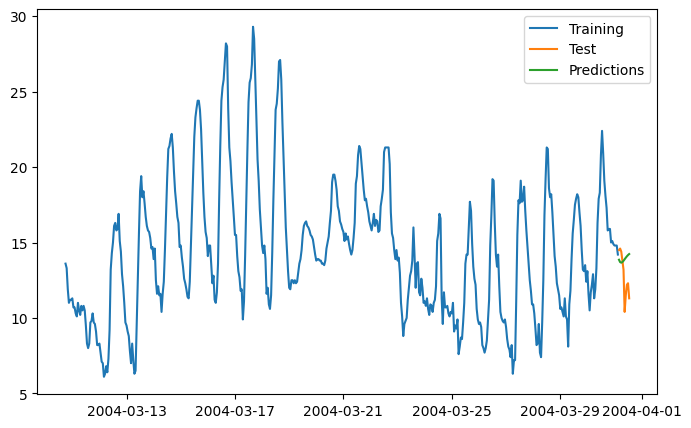

In [53]:
plt.figure(figsize=(8,5))
plt.plot(train, label = 'Training')
plt.plot(test, label = 'Test')
plt.plot(predictions, label = 'Predictions')
plt.legend();

### Agora construa a base para apresentar ao Prophet.

Primeiro selecione as colunas `Datetime` e `T` de `base`, depois renomeie essas colunas para `ds` e `y`, e então exiba a nova base.

In [55]:
base.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Datetime
Datetime,,,,,,,,,,,,,,,,
2004-03-10 18:00:00,3/10/2004,18:00:00,2.6,1360,150,11.9,1046,166,1056,113,1692,1268,13.6,48.9,0.7578,2004-03-10 18:00:00
2004-03-10 19:00:00,3/10/2004,19:00:00,2.0,1292,112,9.4,955,103,1174,92,1559,972,13.3,47.7,0.7255,2004-03-10 19:00:00
2004-03-10 20:00:00,3/10/2004,20:00:00,2.2,1402,88,9.0,939,131,1140,114,1555,1074,11.9,54.0,0.7502,2004-03-10 20:00:00
2004-03-10 21:00:00,3/10/2004,21:00:00,2.2,1376,80,9.2,948,172,1092,122,1584,1203,11.0,60.0,0.7867,2004-03-10 21:00:00
2004-03-10 22:00:00,3/10/2004,22:00:00,1.6,1272,51,6.5,836,131,1205,116,1490,1110,11.2,59.6,0.7888,2004-03-10 22:00:00


In [54]:
base_prophet = base[["Datetime", "T"]]
base_prophet.rename(columns={"Datetime": "ds", "T": "y"}, inplace=True)
base_prophet

/tmp/ipykernel_6187/771719337.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  base_prophet.rename(columns={"Datetime": "ds", "T": "y"}, inplace=True)


,ds,y
Datetime,,
2004-03-10 18:00:00,2004-03-10 18:00:00,13.6
2004-03-10 19:00:00,2004-03-10 19:00:00,13.3
2004-03-10 20:00:00,2004-03-10 20:00:00,11.9
2004-03-10 21:00:00,2004-03-10 21:00:00,11.0
2004-03-10 22:00:00,2004-03-10 22:00:00,11.2
...,...,...
2004-03-31 09:00:00,2004-03-31 09:00:00,10.4
2004-03-31 10:00:00,2004-03-31 10:00:00,11.5
2004-03-31 11:00:00,2004-03-31 11:00:00,12.2


Instancie e treine um modelo do tipo `Prophet`.

"Prever séries temporais de forma automatizada, lidando bem com sazonalidade e feriados" porque o Facebook Prophet é especialmente projetado para lidar com essas características, tornando a previsão mais precisa e acessível, mesmo em condições complexas. Isso permite que faça previsões robustas com facilidade.


In [56]:
model = Prophet()
model.fit(base_prophet)

17:57:55 - cmdstanpy - INFO - Chain [1] start processing
17:57:55 - cmdstanpy - INFO - Chain [1] done processing


In [57]:
print(f"Modo de Sazonalidade: {model.seasonality_mode}")
print(f"Escala de Changepoints: {model.changepoint_prior_scale}")
print(f"Tipo de Crescimento: {model.growth}")


# configurações adicionais ou iniciais
# Mostra os parâmetros principais de configuração
params = {attr: getattr(model, attr) for attr in ['growth', 'changepoint_prior_scale', 'seasonality_mode', 'yearly_seasonality', 'weekly_seasonality', 'daily_seasonality']}
print(params)

Modo de Sazonalidade: additive
Escala de Changepoints: 0.05
Tipo de Crescimento: linear
{'growth': 'linear', 'changepoint_prior_scale': 0.05, 'seasonality_mode': 'additive', 'yearly_seasonality': 'auto', 'weekly_seasonality': 'auto', 'daily_seasonality': 'auto'}


Prepare um dataframe para fazer predições futuras de 24 períodos, mas você também deve informar que a frequência é horária (parâmetro `freq="h"`). Faça e exiba as predições.

In [58]:
future = model.make_future_dataframe(periods=24, freq="h")
forecast = model.predict(future)
forecast.tail(24)

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,daily,daily_lower,daily_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
500,2004-03-31 14:00:00,13.645951,15.530711,21.117740,13.645951,13.645951,4.717289,4.717289,4.717289,4.515098,4.515098,4.515098,0.202190,0.202190,0.202190,0.0,0.0,0.0,18.363239
501,2004-03-31 15:00:00,13.653454,15.499878,21.093782,13.653454,13.653454,4.672016,4.672016,4.672016,4.513007,4.513007,4.513007,0.159009,0.159009,0.159009,0.0,0.0,0.0,18.325470
502,2004-03-31 16:00:00,13.660958,15.228336,20.830946,13.660958,13.660958,4.397556,4.397556,4.397556,4.283678,4.283678,4.283678,0.113878,0.113878,0.113878,0.0,0.0,0.0,18.058514
503,2004-03-31 17:00:00,13.668462,14.788839,20.130208,13.668462,13.668462,3.766446,3.766446,3.766446,3.699613,3.699613,3.699613,0.066833,0.066833,0.066833,0.0,0.0,0.0,17.434908
504,2004-03-31 18:00:00,13.675966,13.622483,19.275620,13.675236,13.676419,2.725410,2.725410,2.725410,2.707492,2.707492,2.707492,0.017918,0.017918,0.017918,0.0,0.0,0.0,16.401375
505,2004-03-31 19:00:00,13.683469,12.276766,17.846744,13.680618,13.686833,1.454425,1.454425,1.454425,1.487235,1.487235,1.487235,-0.032810,-0.032810,-0.032810,0.0,0.0,0.0,15.137894
506,2004-03-31 20:00:00,13.690973,11.487634,16.774957,13.684803,13.699699,0.282007,0.282007,0.282007,0.367291,0.367291,0.367291,-0.085284,-0.085284,-0.085284,0.0,0.0,0.0,13.972980
507,2004-03-31 21:00:00,13.698477,10.459646,15.757232,13.689673,13.712824,-0.561078,-0.561078,-0.561078,-0.421652,-0.421652,-0.421652,-0.139426,-0.139426,-0.139426,0.0,0.0,0.0,13.137399
508,2004-03-31 22:00:00,13.705980,9.824025,15.419030,13.693534,13.725791,-1.103248,-1.103248,-1.103248,-0.908099,-0.908099,-0.908099,-0.195150,-0.195150,-0.195150,0.0,0.0,0.0,12.602732
509,2004-03-31 23:00:00,13.713484,9.452551,14.833774,13.697291,13.738208,-1.552764,-1.552764,-1.552764,-1.300406,-1.300406,-1.300406,-0.252358,-0.252358,-0.252358,0.0,0.0,0.0,12.160720


In [59]:
future

,ds
0,2004-03-10 18:00:00
1,2004-03-10 19:00:00
2,2004-03-10 20:00:00
3,2004-03-10 21:00:00
4,2004-03-10 22:00:00
...,...
519,2004-04-01 09:00:00
520,2004-04-01 10:00:00
521,2004-04-01 11:00:00
522,2004-04-01 12:00:00


In [60]:
# 24 dias *24 horas

In [61]:
24*24

576

In [63]:
base_prophet['ds'].min(), base_prophet['ds'].max()

(Timestamp('2004-03-10 18:00:00'), Timestamp('2004-03-31 13:00:00'))

In [68]:
future.loc[future['ds']> base_prophet['ds'].max()] # valores previstos, 24 horas.

,ds
500,2004-03-31 14:00:00
501,2004-03-31 15:00:00
502,2004-03-31 16:00:00
503,2004-03-31 17:00:00
504,2004-03-31 18:00:00
505,2004-03-31 19:00:00
506,2004-03-31 20:00:00
507,2004-03-31 21:00:00
508,2004-03-31 22:00:00
509,2004-03-31 23:00:00


In [67]:
print(f'quantidade de valores previstos em hora: {len(future.loc[future['ds']> base_prophet['ds'].max()])}.')

quantidade de valores previstos em hora: 24.


Plote as predições com o método `plot` da instância do modelo.

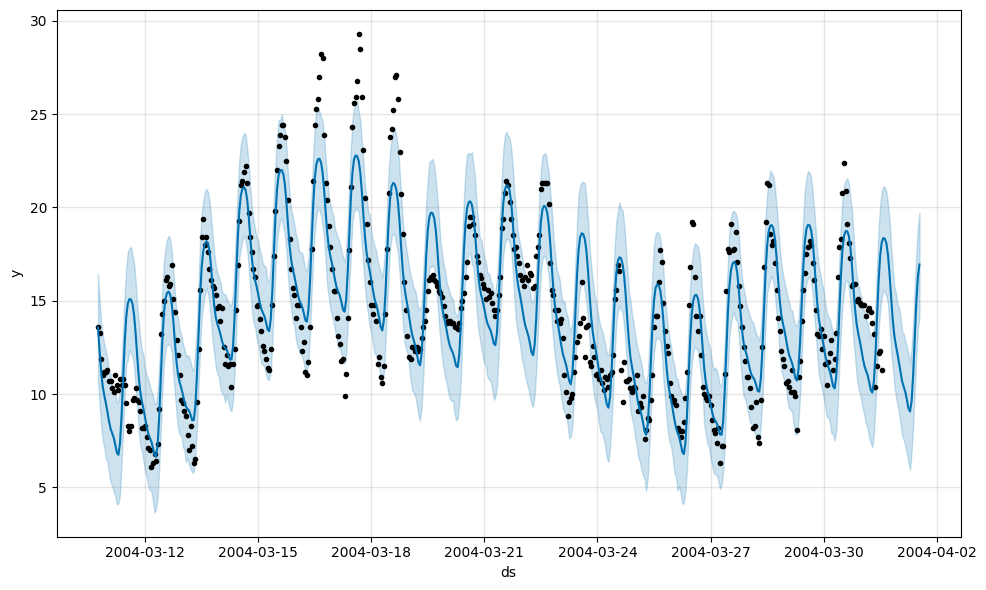

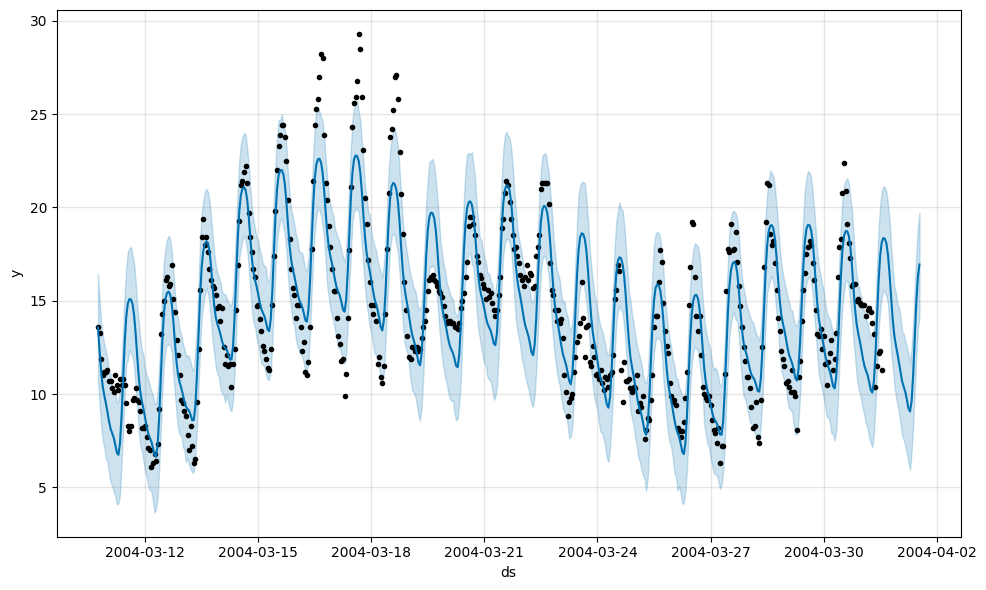

In [69]:
model.plot(forecast)

Também plote os componentes da predição.

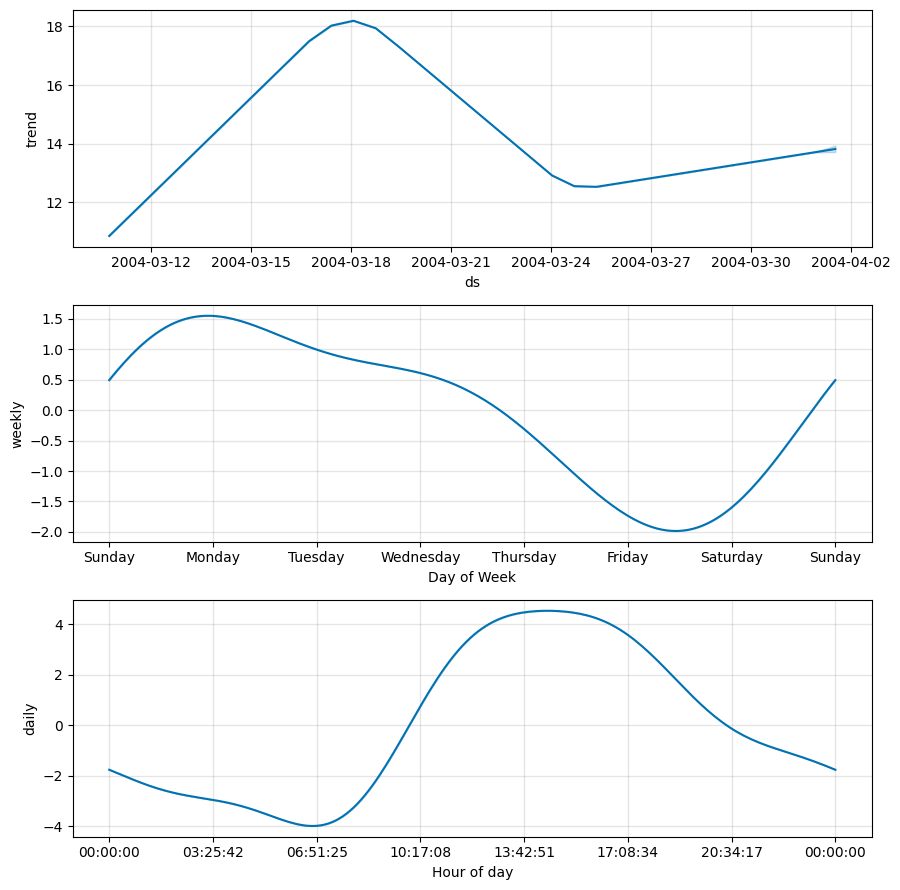

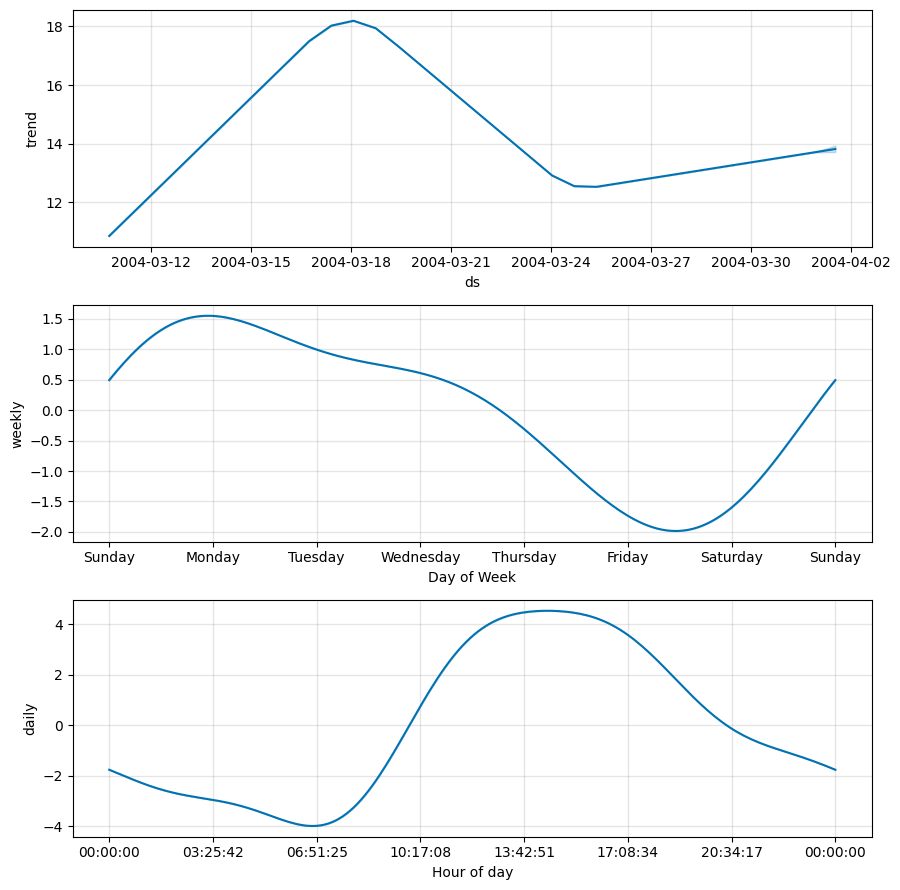

In [71]:
model.plot_components(forecast)

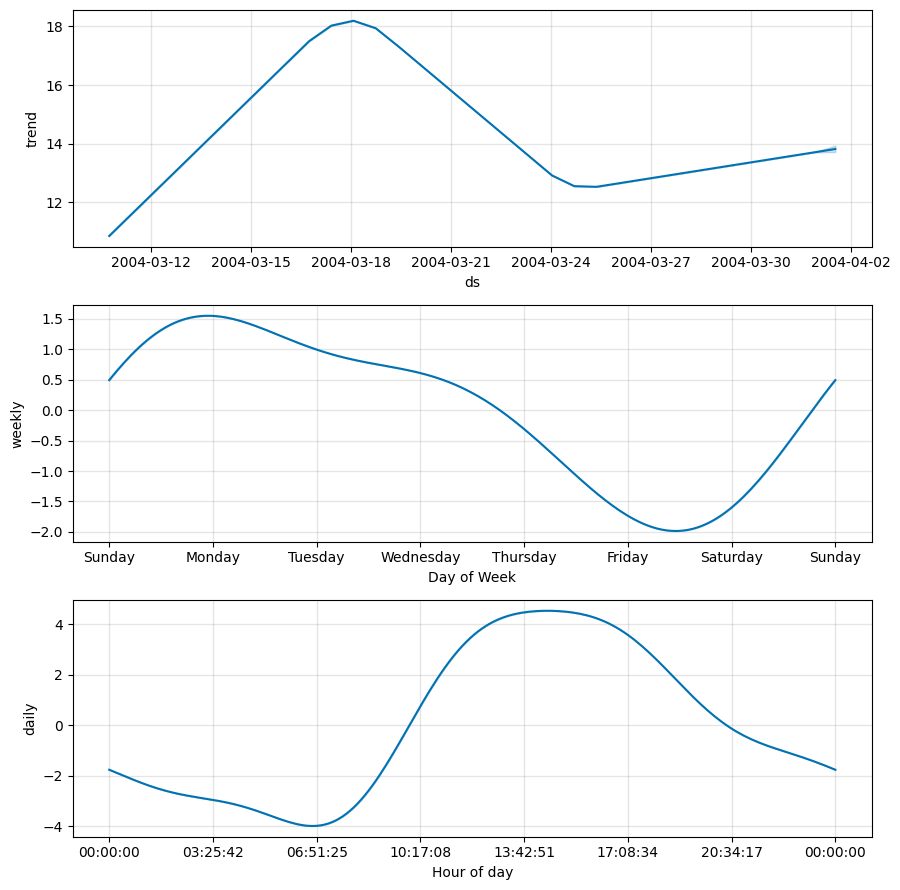

In [72]:
model.plot_components(forecast);

Agora plote as predições com a função `plot_plotly`.

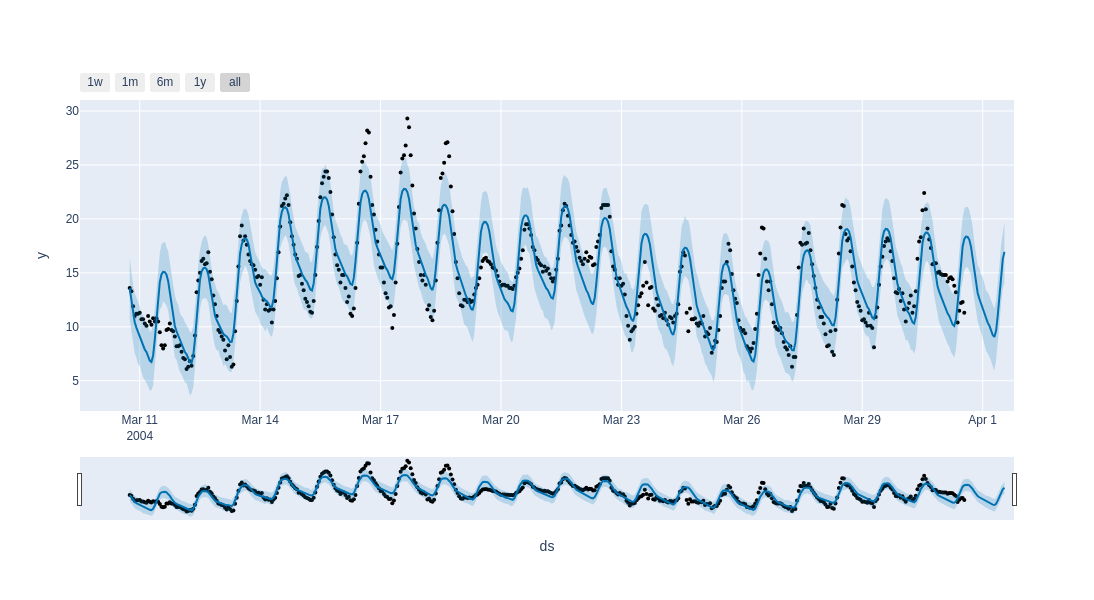

In [73]:
plot_plotly(model, forecast)

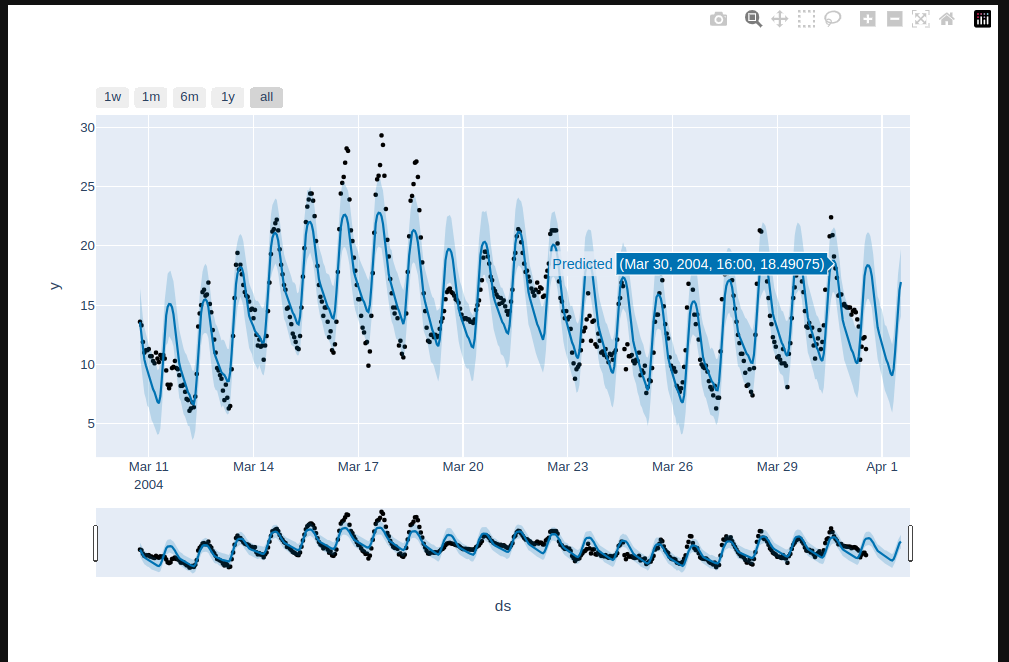

E finalmente plote os componentes com a função `plot_components_plotly`.

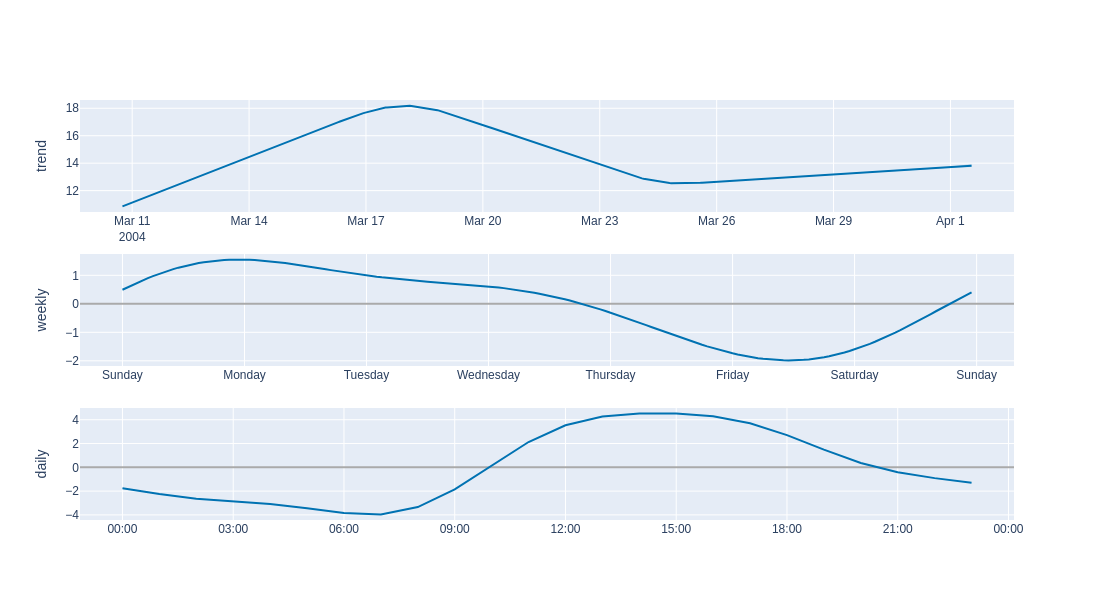

In [74]:
plot_components_plotly(model, forecast)

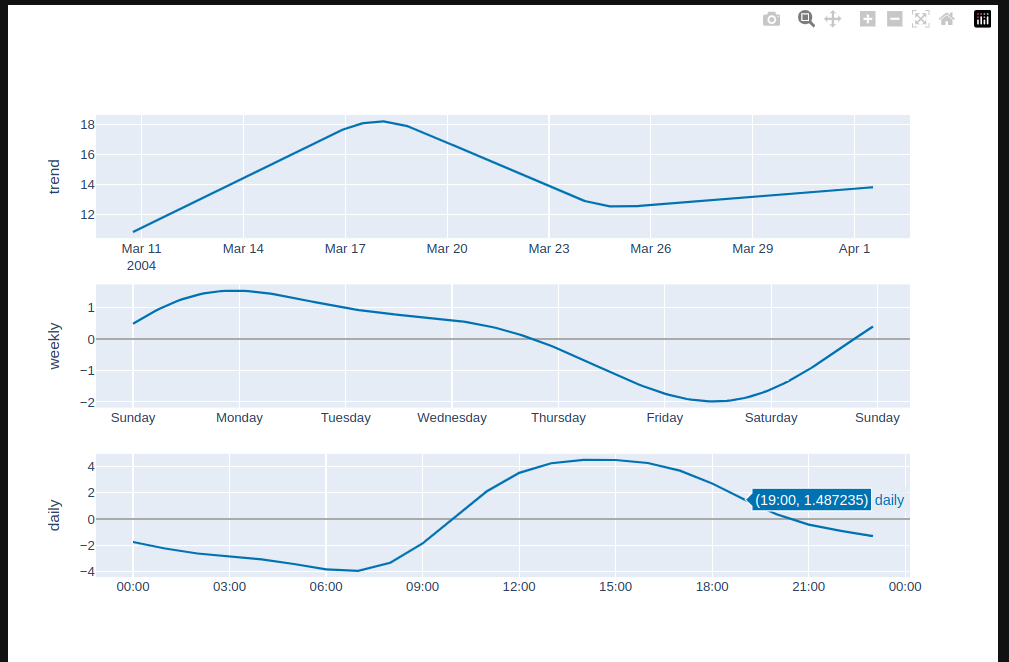